In [ ]:
import pandas as pd
import numpy as np


import sys
sys.path.append('../src')

from data_loader import load_fraud_data, load_ip_data, merge_ip_country
from feature_engineering import run_all
from preprocessor import (remove_duplicates, handle_missing,
                           encode_categoricals, split_features_target,
                           split_and_scale, apply_smote)
from eda import (plot_class_imbalance, plot_numeric_distributions,
                 plot_fraud_by_country, plot_time_since_signup)
# Load all three datasets
fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_df    = pd.read_csv('../data/raw/IpAddress_to_Country.csv')
cc_df    = pd.read_csv('../data/raw/creditcard.csv')

# Quick inspection
for name, df in [('Fraud_Data', fraud_df), ('IpAddress', ip_df), ('creditcard', cc_df)]:
    print(f"\n=== {name} ===")
    print(f"Shape: {df.shape}")
    print(df.dtypes)
    print(df.isnull().sum())
    print(df.duplicated().sum(), "duplicates")


=== Fraud_Data ===
Shape: (151112, 11)
user_id             int64
signup_time        object
purchase_time      object
purchase_value      int64
device_id          object
source             object
browser            object
sex                object
age                 int64
ip_address        float64
class               int64
dtype: object
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64
0 duplicates

=== IpAddress ===
Shape: (138846, 3)
lower_bound_ip_address    float64
upper_bound_ip_address      int64
country                    object
dtype: object
lower_bound_ip_address    0
upper_bound_ip_address    0
country                   0
dtype: int64
0 duplicates

=== creditcard ===
Shape: (284807, 31)
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6

In [5]:
# --- Fraud_Data ---
fraud_df.drop_duplicates(inplace=True)

# Parse datetime columns
fraud_df['signup_time']   = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

# Drop or impute nulls — document your choice
# e.g. if <5% missing: drop rows; if >5%: impute with median/mode
# fraud_df.dropna(inplace=True)  # or:
# fraud_df['some_col'].fillna(fraud_df['some_col'].median(), inplace=True)

# --- creditcard ---
cc_df.drop_duplicates(inplace=True)
cc_df.dropna(inplace=True)   # PCA features, safe to drop tiny null count

Fraud_Data class dist:
 class
0    0.906354
1    0.093646
Name: proportion, dtype: float64
creditcard class dist:
 Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64


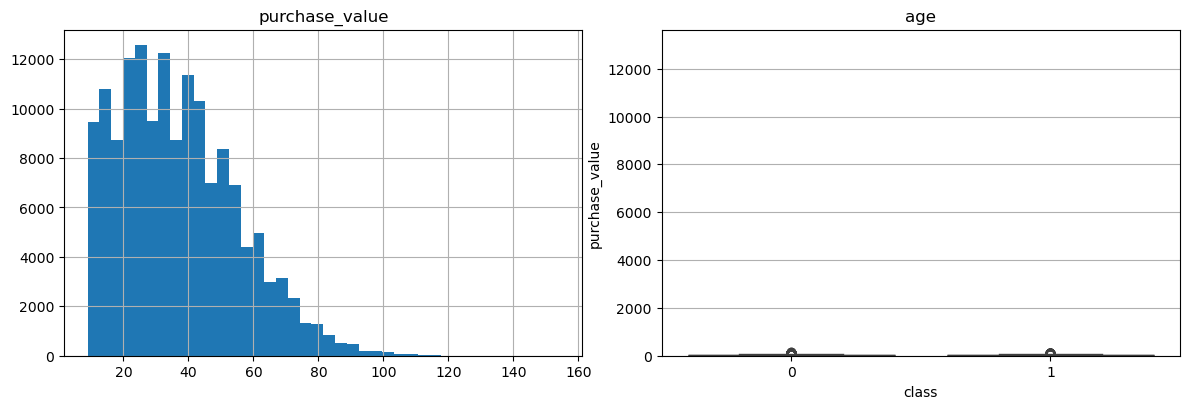

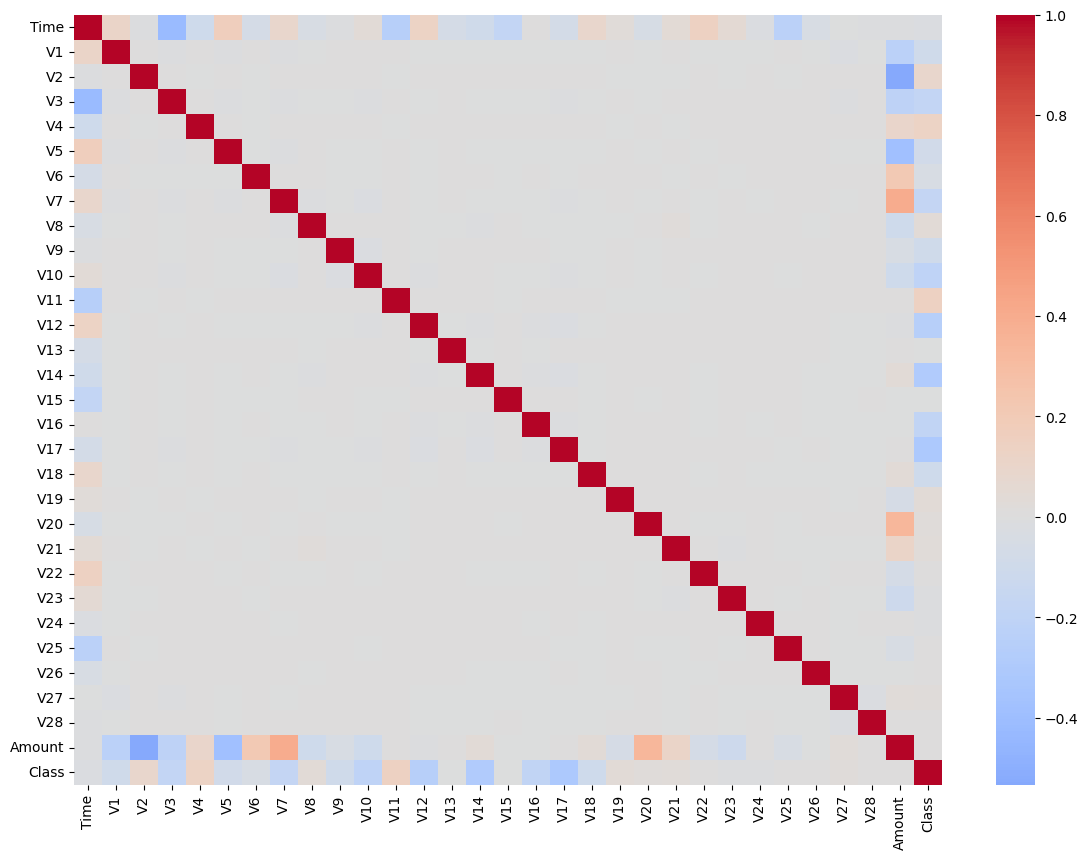

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class imbalance check (do this for BOTH datasets)
print("Fraud_Data class dist:\n", fraud_df['class'].value_counts(normalize=True))
print("creditcard class dist:\n", cc_df['Class'].value_counts(normalize=True))

# Univariate — key numeric columns
fraud_df[['purchase_value', 'age']].hist(bins=40, figsize=(12,4))
plt.tight_layout(); plt.savefig('../data/processed/fraud_univariate.png')

# Bivariate — fraud vs purchase_value
sns.boxplot(x='class', y='purchase_value', data=fraud_df)
plt.savefig('../data/processed/fraud_vs_value.png')

# Correlation heatmap for creditcard
plt.figure(figsize=(14,10))
sns.heatmap(cc_df.corr(), cmap='coolwarm', center=0)
plt.savefig('../data/processed/cc_corr.png')

In [10]:
# Convert IP to integer
def ip_to_int(ip):
    parts = str(ip).split('.')
    return sum(int(p) << (8 * (3 - i)) for i, p in enumerate(parts))

fraud_df['ip_int'] = fraud_df['ip_address'].apply(ip_to_int)
ip_df['lower_int'] = ip_df['lower_bound_ip_address'].apply(ip_to_int)
ip_df['upper_int'] = ip_df['upper_bound_ip_address'].apply(ip_to_int)

# Range-based merge using merge_asof
fraud_sorted = fraud_df.sort_values('ip_int')
ip_sorted    = ip_df.sort_values('lower_int')

merged = pd.merge_asof(
    fraud_sorted,
    ip_sorted[['lower_int', 'upper_int', 'country']],
    left_on='ip_int',
    right_on='lower_int',
    direction='backward'
)

# Keep only valid matches (ip_int within the range)
merged.loc[merged['ip_int'] > merged['upper_int'], 'country'] = 'Unknown'

# Fraud rate by country
fraud_by_country = merged.groupby('country')['class'].mean().sort_values(ascending=False)
print(fraud_by_country.head(10))

country
Turkmenistan    1.000000
Sri Lanka       0.419355
Namibia         0.416667
Luxembourg      0.383562
Bermuda         0.333333
Peru            0.262712
Tunisia         0.262712
Ecuador         0.261682
Bolivia         0.254902
Kuwait          0.233333
Name: class, dtype: float64


In [11]:
df = merged.copy()

# time_since_signup in hours
df['time_since_signup'] = (
    df['purchase_time'] - df['signup_time']
).dt.total_seconds() / 3600

# Time features
df['hour_of_day']  = df['purchase_time'].dt.hour
df['day_of_week']  = df['purchase_time'].dt.dayofweek

# Transaction velocity — transactions per user in last 24h window
df = df.sort_values(['user_id', 'purchase_time'])
df['txn_count_24h'] = df.groupby('user_id')['purchase_time'].transform(
    lambda x: x.expanding().count()
)

# Purchase frequency per user overall
df['user_txn_freq'] = df.groupby('user_id')['user_id'].transform('count')

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# One-hot encode categoricals
df_encoded = pd.get_dummies(df, columns=['source', 'browser', 'sex', 'country'])

# Feature/target split
drop_cols = ['user_id', 'signup_time', 'purchase_time', 'ip_address',
             'ip_int', 'lower_int', 'upper_int', 'device_id', 'class']
X = df_encoded.drop(columns=drop_cols)
y = df_encoded['class']

# Stratified split — BEFORE any resampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # fit on train only!

# SMOTE on train set ONLY
print("Before SMOTE:", y_train.value_counts())
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)
print("After SMOTE:", pd.Series(y_train_res).value_counts())

# Save processed data
np.save('../data/processed/X_train.npy', X_train_res)
np.save('../data/processed/X_test.npy',  X_test_scaled)
np.save('../data/processed/y_train.npy', y_train_res)
np.save('../data/processed/y_test.npy',  y_test.values)

Before SMOTE: class
0    109568
1     11321
Name: count, dtype: int64
After SMOTE: class
0    109568
1    109568
Name: count, dtype: int64
